# Determining the number of neutrino generations from Z-boson decays #

In this exercise, you will take a closer look at the $e^+e^-\to\mu^+\mu^-$ process. By the end of this exercise, you should have developed a good understanding of the lineshape of the Z-boson resonance and the meaning of partial and total decay widths. You will have learned how to generate "toy" events and how to fit a functional form to a (simulated) data histogram, extracting a parameter of interest.

In [3]:
from utils import *

# This coursework makes use of the techniques described in the example notebook within this repository. #

## The expression below gives the cross section of the processes $e^{+}e^{-}\rightarrow  \mu^+\mu^-$, as a function of the centre of mass energy $\sqrt{s}$. The parameters $m_{Z}$, $\Gamma_{Z}$ denote the mass and width of the $Z^0$ boson respectively ##

$$\sigma(e^{+}e^{-}\rightarrow  \mu^+\mu^-) = \frac{12\pi s}{m_{Z}^{2}}\frac{\Gamma_{e^+e^-}\Gamma_{\mu^+\mu^-}}{(s-m_{Z}^{2})^{2}+m_{Z}^{2}\Gamma_{Z}^{2}}$$

# Question 1 [8 marks] #

- What is the key assumption regarding the range of $\sqrt{s}$ values for which the above expression holds?
- What is the physical meaning of $\Gamma_Z$?
- What is the physical meaning of $\Gamma_{e^+e^-}$ and $\Gamma_{\mu^+\mu^-}$?

- The interaction $e^+e^-\to\mu^+\mu^-$ can be mediated by either a photon or Z-boson, but the given equation specifies a Z-boson mediated interaction via parameters $m_{Z}$ & $\Gamma_{Z}$. Therefore, Z-boson exchange contributions to the cross section must be maximised and photon exchange neglected. This is achieved by minimising the denominator, which happens at and near $\sqrt{s} = m_z$. Assuming that the centre of mass energy is in a range near the Z-boson mass leads to the expression holding.

- $\Gamma_Z$ is the total decay width of the $Z^{0}$, or the sum of all possible channels over which $Z^{0}$ might decay. This value relates to its lifetime, where a larger width gives inversely proportional lifetime with constant of proportionality $\hbar$. Physically, it can be seen as the finite width of the $Z^{0}$ resonance peak on a graph of interaction cross section against energy.

- $\Gamma_{e^+e^-}$ and $\Gamma_{\mu^+\mu^-}$ are partial decay widths of $Z^{0}\rightarrow  e^{+}e^{-}$ and $Z^{0}\rightarrow  \mu^{+}\mu^{-}$ respectively. They contribute to $\Gamma_Z$ as they represent the strength of 2 possible decay channels and physically show the strength of the $Z^{0}$ interactions with each pair. The branching fraction of partial decay width / total decay width expresses physcial probability of the stated final state appearing after decay.

# Question 2 [4 marks] # 
- Make a plot of the cross-section expression given above as a function of the centre of mass energy $\sqrt{s}$ in the range between 0.210GeV and 120GeV, using the following values of the parameters $m_Z$, $\Gamma_Z$, $\Gamma_{e^+e^-}$, $\Gamma_{\mu^+\mu^-}$:\
$m_Z$ = 91.18 GeV\
$\Gamma_Z$ = 2.496 GeV\
$\Gamma_{e^+e^-}$ = $\Gamma_{\mu^+\mu^-}$ = 0.084 GeV

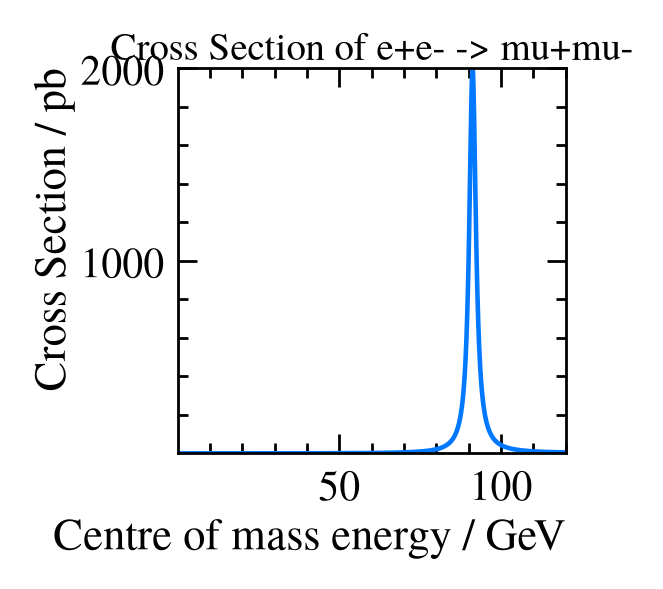

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Constants 
mz = 91.18 # GeV, Z bozon mass
gamma_z = 2.496 # Gev, Z boson width
gamma_p = 0.084 # GeV, partial decay widths of e+, e-, mu+, mu-
sqrt_s_min = 0.210
sqrt_s_max = 120

# No. of points on each axis
num_points = 5000 

# X-axis
sqrt_s_values = np.linspace(sqrt_s_min, sqrt_s_max, num_points) 

# Y-axis
cross_sections = (12 * np.pi * sqrt_s_values**2 / mz**2) * (gamma_p**2 / ((sqrt_s_values**2 - mz**2)**2 + (mz * gamma_z)**2))

# Convert to (pico)barns
cross_sections = cross_sections * 0.389379e9 # GeV^-2 to pb

# Plot
plt.figure(figsize=(5, 5)) 
plt.tight_layout()
plt.plot(sqrt_s_values, cross_sections)
plt.title("Cross Section of e+e- -> mu+mu-")
plt.xlabel("Centre of mass energy / GeV")
plt.ylabel("Cross Section / pb")
plt.show()

# Question 3 [8 marks] #
- Starting from the value of $\Gamma_Z$ given in the cell above, explain how we arrived at the values of the parameters $\Gamma_{e^+e^-}$ and $\Gamma_{\mu^+\mu^-}$ given in the cell above. You are given that $\rm{BF(Z^0\to e^+e^-)} = \rm{BF(Z^0\to \mu^+\mu^-)} = 3.366\%$ 
- The plot you have made in Question 2 should show that the cross-section continues to decrease all the way to twice the muon mass (0.210 GeV). Is this what you would expect to observe in an $e^+e^-\to \mu^+\mu^-$ process? **Hint: Think of what other force carrier can mediate the $e^+e^-\to\mu^+\mu^-$ process?** 

- The branching fraction, which is defined as the partial decay width divided by the particle's total decay width, for a $Z_0$ decaying into a $e^+e^-$ or $\mu ^+ \mu ^-$ is provided as 3.366%. Therefore, the partial decay width is 3.366% of 2.496 GeV, which is 0.084 GeV.

- If a photon mediated the process the cross section would immediately peak after ~0.211 GeV (centre of mass energy must be at least above muon-antimuon mass) however the plot from question 2 only accounts for $Z_0$ as a mediator. As energy climbs to 91.2 GeV, quantum resonance occurs near the rest mass of the $Z_0$ boson, drastically increasing the cross section near this point. In reality, both processes occur, so a plot of a general $e^+e^-\to \mu^+\mu^-$ process would include both mediators, superposing both graph shapes.

# Question 4 [12 marks] #
- Which parameter would you modify in the expression of the cross section given above in order to describe the process $e^+e^- \to\mathrm{hadrons}$?
- What would be the telling signature of $e^+e^- \to Z^{0}\to\mathrm{q\bar{q}}$ where $q$ denotes a quark?  
- For an onshell $Z^0$ boson, what quark pairs can the $Z^0$ decay into?


# Question 5 [12 marks] #
- The example notebook (particle_project_example.ipynb) shows you how to generate a set of events from a given distribution using the "gen_data" function of utils.py. Using this function, generate 20,000,000 values of $\sqrt{s}$ sampled from the cross-section expression for $e^+e^- \to Z^{0}\to\mathrm{\mu^+\mu^-}$ you used in Question 2. Make sure you set the $\sqrt{s}$ range of values to generate as $87~\rm{GeV}<\sqrt{s}<95~\rm{GeV}$

# Question 6 [8 marks]
- Make a histogram of the $\sqrt{s}$  values you generated in Question 5.  **Tip: Make sure that the x-axis range of the histogram matches that of data you generated. Also we recommend your histogram to have at least 100 bins.**

# Question 7 [28 marks] #
- Devise an approach to determine the number of generations of neutrinos by performing a fit to the histogram you created in the previous cell. 
    - You are given that in the SM: $\Gamma_{\nu_{l}\bar{\nu}_{l}}=2\Gamma_{l^+l^-}$, where $l$ denotes a specific lepton generation
    - You can also assume the values: $\Gamma_{q\bar{q}}=1.744$GeV, $\Gamma_{e^+e^-}=\Gamma_{\mu^+\mu^-}=\Gamma_{\tau^+\tau^-}=0.083984$GeV

**Hint: Take a look at particle_project_example.ipynb for an example of how to fit a function to a histogram. Make sure you also look at how to fix a parameter so that it is not varying in the fit**

# Question 8 [20 marks] #

- Is the number you obtained from your fit statistically compatible with three generations?
- What are the systematic uncertainties associated with the various inputs provided in Question 7? 
- Can you think of ways to estimate the effect of systematic uncertainties?

**Hint: Take a look at the properties of the Z boson given in the Particle Data Group link https://pdglive.lbl.gov/Particle.action?node=S044&init=0**